# Datos Faltantes

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [3]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
391,-0.023677,-0.044642,-0.069797,-0.064199,-0.059359,-0.050478,0.019187,-0.039493,-0.089133,-0.050783,63.0
213,0.001751,-0.044642,-0.070875,-0.022885,-0.001569,-0.001001,0.026550,-0.039493,-0.022517,0.007207,49.0
208,0.030811,-0.044642,0.040140,0.076958,0.017694,0.037830,-0.028674,0.034309,-0.001496,0.119043,155.0
402,0.110727,0.050680,-0.033151,-0.022885,-0.004321,0.020293,-0.061809,0.071210,0.015568,0.044485,168.0
277,-0.034575,-0.044642,-0.059019,0.001215,-0.053855,-0.078035,0.067048,-0.076395,-0.021395,0.015491,64.0
329,-0.012780,0.050680,-0.055785,-0.002228,-0.027712,-0.029184,0.019187,-0.039493,-0.017056,0.044485,135.0
185,-0.074533,0.050680,-0.018062,0.008101,-0.019456,-0.024800,-0.065491,0.034309,0.067318,-0.017646,101.0
352,0.012648,0.050680,-0.071952,-0.046985,-0.051103,-0.097137,0.118591,-0.076395,-0.020292,-0.038357,77.0
154,0.067136,0.050680,0.020739,-0.005670,0.020446,0.026243,-0.002903,-0.002592,0.008641,0.003064,197.0
374,-0.107226,-0.044642,-0.034229,-0.067642,-0.063487,-0.070520,0.008142,-0.039493,-0.000612,-0.079778,140.0


In [4]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [5]:
valores_faltantes = data.isnull().sum()
print("Valores faltantes por columna: ")
print(valores_faltantes)

Valores faltantes por columna: 
age        0
sex        0
bmi       44
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64


### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [7]:
data_simple = data.copy()

#Vamos a inicializar el imputador con la media
imputer = SimpleImputer(strategy='mean')
data_simple['bmi'] = imputer.fit_transform(data_simple[['bmi']])

#Verificar que no haya nulos en 'bmi'
print("Faltantes en 'bmi' tras imputacioón simple: ", data_simple['bmi'].isnull().sum())

Faltantes en 'bmi' tras imputacioón simple:  0


### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [8]:
#Hacemos una copia para imputar por KNN
data_knn = data.copy()

#Imputaremos usando 5 vecinos como estándar
knn_imputer = KNNImputer(n_neighbors=5)
data_knn[['bmi', 'bp']] = knn_imputer.fit_transform(data_knn[['bmi', 'bp']])

print("Faltantes en 'bmi' y 'bp' tras KNNImputer:")
print(data_knn[['bmi', 'bp']].isnull().sum())

# Comparación rápida de las medias obtenidas
print("\n--- Comparación de Medias en 'bmi' ---")
print(f"Original (omitiendo nulos): {data['bmi'].mean():.6f}")
print(f"Imputación Simple (Media): {data_simple['bmi'].mean():.6f}")
print(f"Imputación Avanzada (KNN): {data_knn['bmi'].mean():.6f}")

Faltantes en 'bmi' y 'bp' tras KNNImputer:
bmi    0
bp     0
dtype: int64

--- Comparación de Medias en 'bmi' ---
Original (omitiendo nulos): -0.000205
Imputación Simple (Media): -0.000205
Imputación Avanzada (KNN): 0.000112


### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

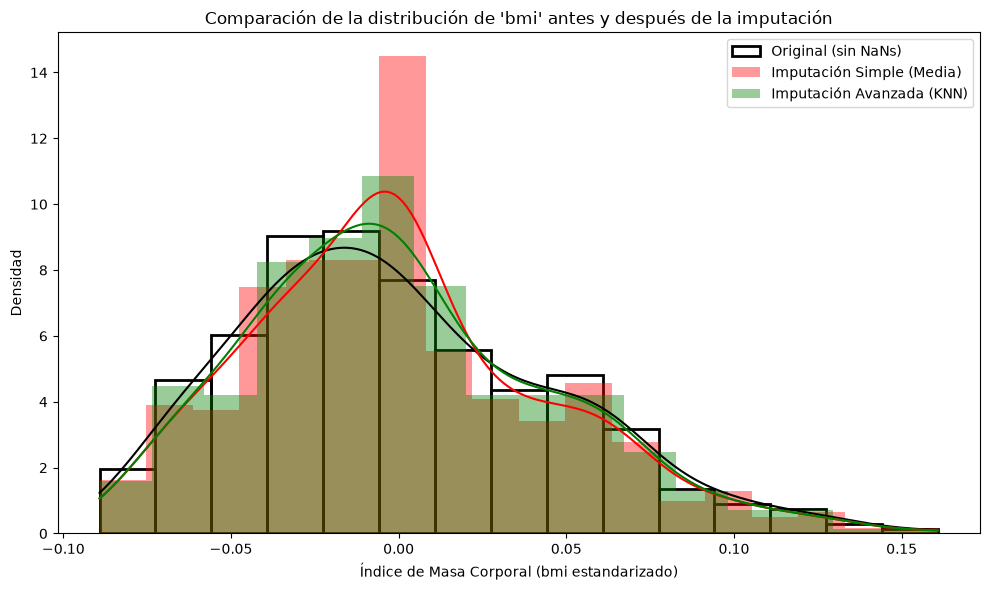

In [9]:
plt.figure(figsize=(10, 6))

# Trazar la distribución original (ignorando los valores faltantes)
sns.histplot(data['bmi'].dropna(), color='black', label='Original (sin NaNs)', kde=True, stat="density", fill=False, linewidth=2)

# Trazar la distribución con Imputación Simple
sns.histplot(data_simple['bmi'], color='red', label='Imputación Simple (Media)', kde=True, stat="density", alpha=0.4, linewidth=0)

# Trazar la distribución con KNN
sns.histplot(data_knn['bmi'], color='green', label='Imputación Avanzada (KNN)', kde=True, stat="density", alpha=0.4, linewidth=0)

# Configuraciones del gráfico
plt.title("Comparación de la distribución de 'bmi' antes y después de la imputación")
plt.xlabel("Índice de Masa Corporal (bmi estandarizado)")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()
plt.show()